In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

from huggingface_hub import login
from datasets import load_dataset

df = pd.read_pickle('ChessGames.pkl')
df_moves = pd.read_pickle('ChessGamesWithMoves.pkl')

In [46]:
sns.set_style("whitegrid")

In [47]:
df["AvgElo"] = df[["WhiteElo", "BlackElo"]].mean(axis=1)
df["IsDraw"] = (df["Result"] == "1/2-1/2").astype(int)

In [48]:
game_key = ["Event", "White", "Black", "WhiteElo", "BlackElo"]
game_result = df[game_key + ["Result"]].drop_duplicates()

In [49]:
side_blunders = (
    df_moves.groupby(game_key + ["Is_White_Turn"])["Target_Is_Blunder"]
    .sum()
    .unstack(fill_value=0)
    .rename(columns={1: "WhiteBlunders", 0: "BlackBlunders"})
    .reset_index()
)

merged = side_blunders.merge(game_result, on=game_key, how="inner")
merged["WhiteWon"] = (merged["Result"] == "1-0").astype(int)
merged["IsDecisive"] = (merged["Result"] != "1/2-1/2").astype(int)
merged["TotalBlunders"] = merged["WhiteBlunders"] + merged["BlackBlunders"]
merged["BlunderDiff"] = merged["BlackBlunders"] - merged["WhiteBlunders"]  # positive = White blundered less

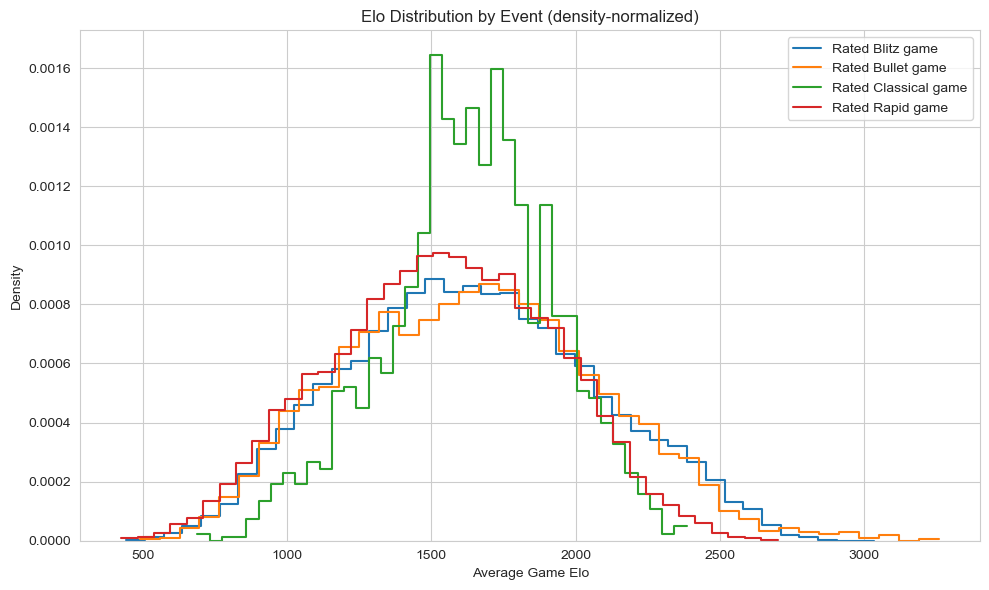

In [50]:
plt.figure(figsize=(10, 6))
for event, sub in df.groupby("Event"):
    sns.histplot(sub["AvgElo"], stat="density", element="step", fill=False,
                 label=event, bins=40)
plt.title("Elo Distribution by Event (density-normalized)")
plt.xlabel("Average Game Elo")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

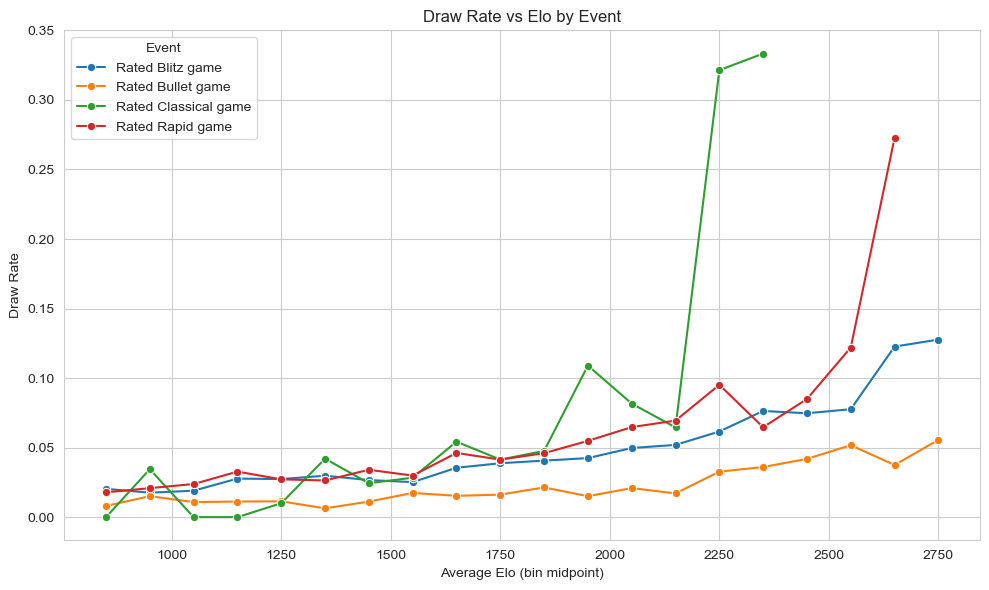

In [51]:
df["EloBin"] = pd.cut(df["AvgElo"], bins=np.arange(800, 2900, 100))

draw_rate = (
    df.groupby(["Event", "EloBin"], observed=True)["IsDraw"]
    .mean()
    .reset_index()
)
draw_rate["EloMid"] = draw_rate["EloBin"].apply(lambda x: x.mid).astype(float)

plt.figure(figsize=(10, 6))
sns.lineplot(data=draw_rate, x="EloMid", y="IsDraw", hue="Event", marker="o")
plt.title("Draw Rate vs Elo by Event")
plt.xlabel("Average Elo (bin midpoint)")
plt.ylabel("Draw Rate")
plt.tight_layout()
plt.show()

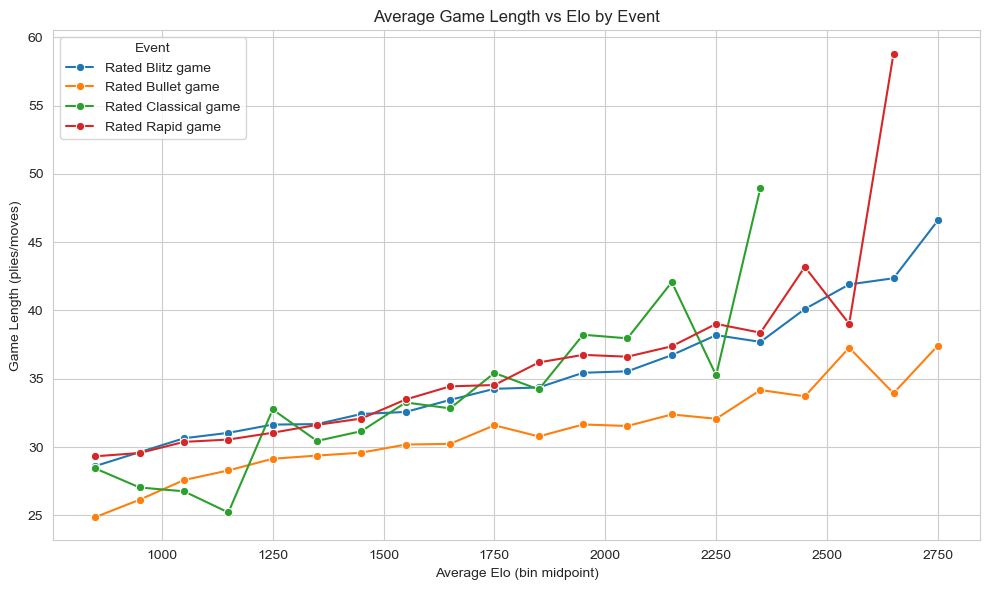

In [52]:
length_by_elo = (
    df.groupby(["Event", "EloBin"], observed=True)["GameLength"]
    .mean()
    .reset_index()
)
length_by_elo["EloMid"] = length_by_elo["EloBin"].apply(lambda x: x.mid).astype(float)

plt.figure(figsize=(10, 6))
sns.lineplot(data=length_by_elo, x="EloMid", y="GameLength", hue="Event", marker="o")
plt.title("Average Game Length vs Elo by Event")
plt.xlabel("Average Elo (bin midpoint)")
plt.ylabel("Game Length (plies/moves)")
plt.tight_layout()
plt.show()

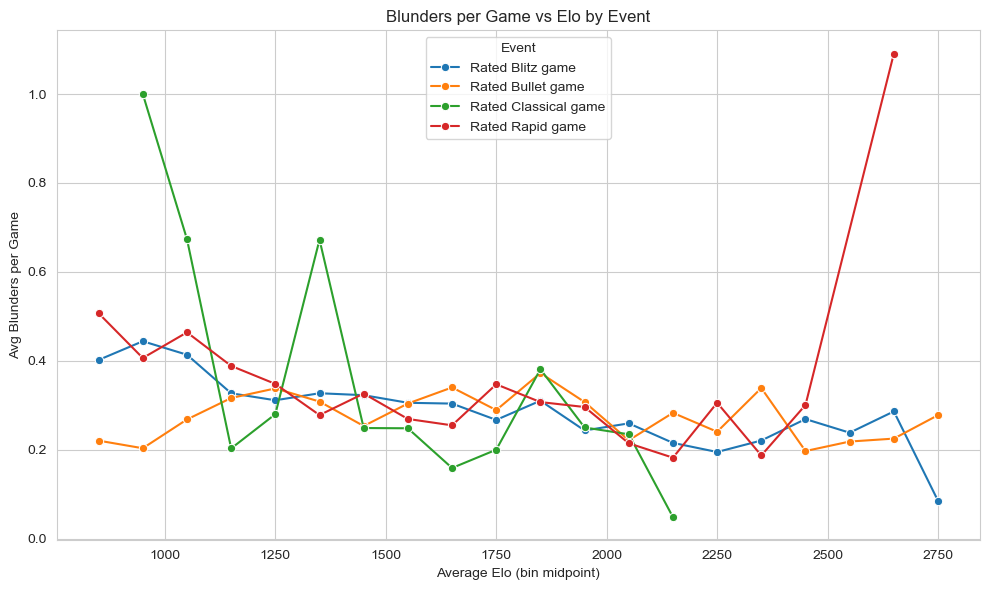

In [53]:
df_moves["AvgElo"] = df_moves[["WhiteElo", "BlackElo"]].mean(axis=1)
df_moves["EloBin"] = pd.cut(df_moves["AvgElo"], bins=np.arange(800, 2900, 100))

# 4a. Blunders per game by elo (normalize by #games, not #moves, to capture "per game" rate)
blunders_per_game = (
    df_moves.groupby(["Event", "EloBin"], observed=True)
    .apply(lambda g: g["Target_Is_Blunder"].sum() / g["White"].nunique() if g["White"].nunique() else np.nan
           , include_groups=False)
    .reset_index(name="BlunderRatePerGame")
)
# safer: use unique game id if available, else count distinct (White,Black,Event) combos
# Assuming there's no explicit game_id, approximate using groupby on original df game count instead:
games_per_bin = (
    df.assign(AvgElo=df[["WhiteElo","BlackElo"]].mean(axis=1))
      .assign(EloBin=lambda d: pd.cut(d["AvgElo"], bins=np.arange(800, 2900, 100)))
      .groupby(["Event", "EloBin"], observed=True)
      .size()
      .reset_index(name="NumGames")
)
blunder_sum = (
    df_moves.groupby(["Event", "EloBin"], observed=True)["Target_Is_Blunder"]
    .sum()
    .reset_index(name="TotalBlunders")
)
blunder_stats = blunder_sum.merge(games_per_bin, on=["Event", "EloBin"], how="left")
blunder_stats["BlunderRatePerGame"] = blunder_stats["TotalBlunders"] / blunder_stats["NumGames"]
blunder_stats["EloMid"] = blunder_stats["EloBin"].apply(lambda x: x.mid).astype(float)

plt.figure(figsize=(10, 6))
sns.lineplot(data=blunder_stats, x="EloMid", y="BlunderRatePerGame", hue="Event", marker="o")
plt.title("Blunders per Game vs Elo by Event")
plt.xlabel("Average Elo (bin midpoint)")
plt.ylabel("Avg Blunders per Game")
plt.tight_layout()
plt.show()


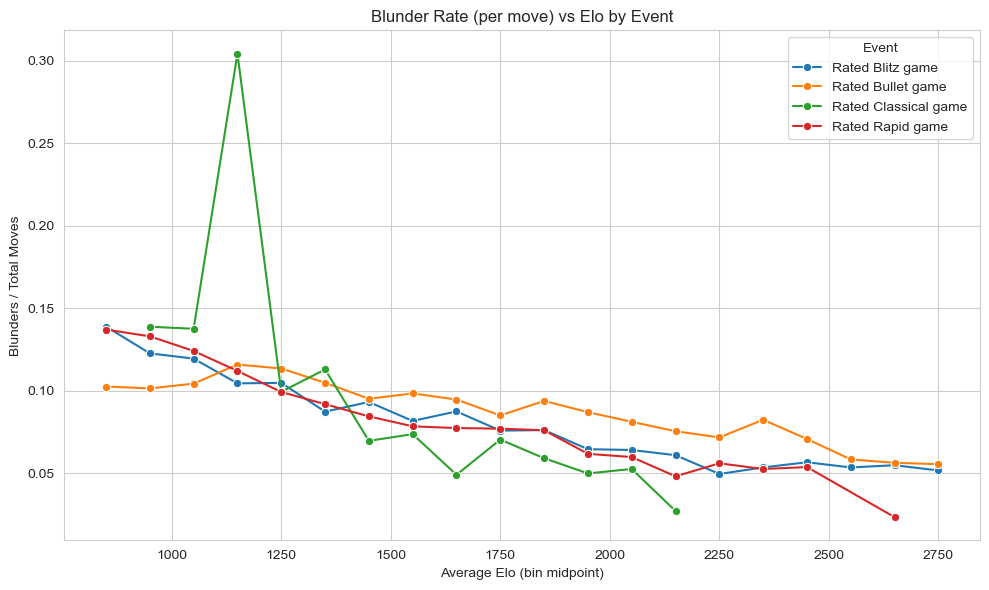

In [54]:
move_counts = (
    df_moves.groupby(["Event", "EloBin"], observed=True)
    .size()
    .reset_index(name="TotalMoves")
)
blunder_stats = blunder_stats.merge(move_counts, on=["Event", "EloBin"])
blunder_stats["BlunderRatePerMove"] = blunder_stats["TotalBlunders"] / blunder_stats["TotalMoves"]

plt.figure(figsize=(10, 6))
sns.lineplot(data=blunder_stats, x="EloMid", y="BlunderRatePerMove", hue="Event", marker="o")
plt.title("Blunder Rate (per move) vs Elo by Event")
plt.xlabel("Average Elo (bin midpoint)")
plt.ylabel("Blunders / Total Moves")
plt.tight_layout()
plt.show()

In [ ]:
CAP = 1000
df_moves["Eval_Before_clipped"] = df_moves["Eval_Before"].clip(-CAP, CAP)
df_moves["Eval_After_clipped"] = df_moves["Eval_After"].clip(-CAP, CAP)
df_moves["Eval_Drop_clipped"] = (df_moves["Eval_Before_clipped"] - df_moves["Eval_After_clipped"]).abs()

In [57]:
is_mate_score = (df_moves["Eval_Before"].abs() >= 10000) | (df_moves["Eval_After"].abs() >= 10000)
df_moves_no_mate = df_moves[~is_mate_score]

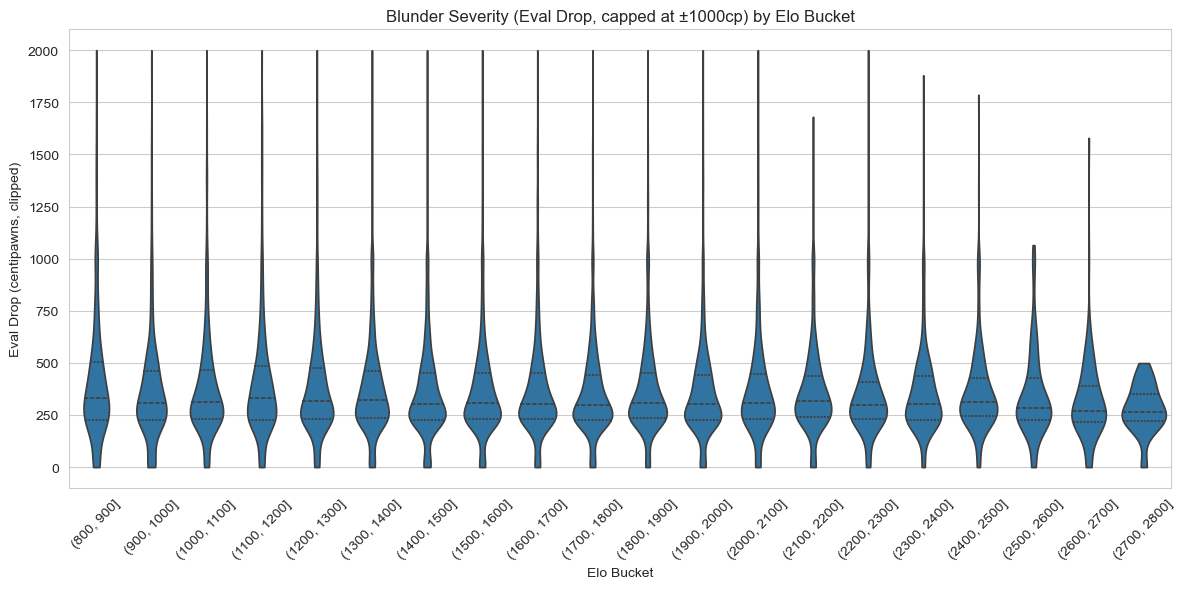

In [60]:
CAP = 1000
df_moves["Eval_Before_clipped"] = df_moves["Eval_Before"].clip(-CAP, CAP)
df_moves["Eval_After_clipped"] = df_moves["Eval_After"].clip(-CAP, CAP)
df_moves["Eval_Drop_clipped"] = (df_moves["Eval_Before_clipped"] - df_moves["Eval_After_clipped"]).abs()

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_moves[df_moves["Target_Is_Blunder"] == 1],
    x="EloBin", y="Eval_Drop_clipped",
    cut=0, inner="quartile"
)
plt.xticks(rotation=45)
plt.title(f"Blunder Severity (Eval Drop, capped at ±{CAP}cp) by Elo Bucket")
plt.xlabel("Elo Bucket")
plt.ylabel("Eval Drop (centipawns, clipped)")
plt.tight_layout()
plt.show()

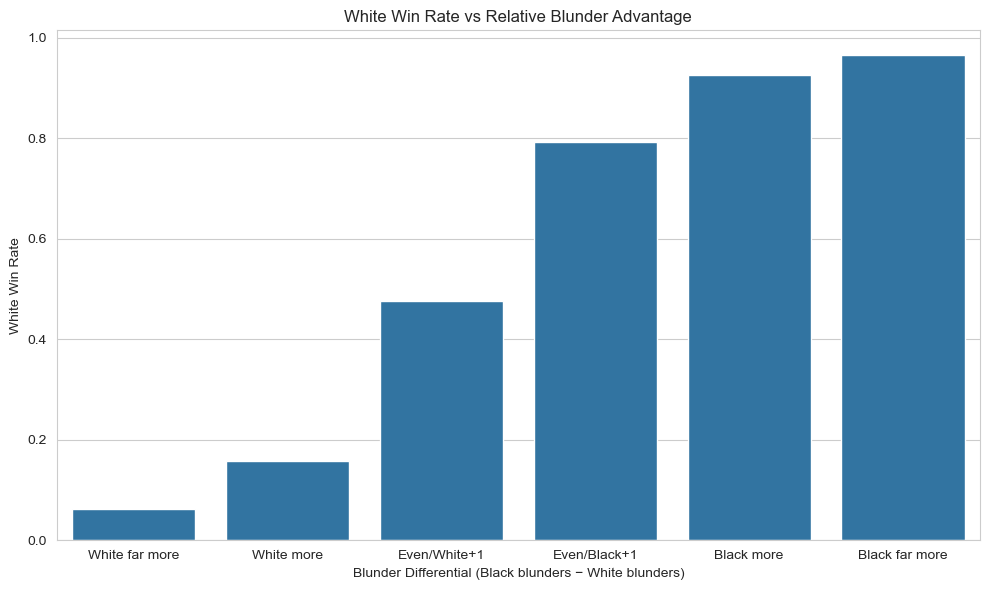

In [56]:
merged["DiffBucket"] = pd.cut(merged["BlunderDiff"], bins=[-100,-3,-1,0,1,3,100],
                                labels=["White far more","White more","Even/White+1","Even/Black+1","Black more","Black far more"])
win_vs_diff = (
    merged.groupby("DiffBucket", observed=True)["WhiteWon"]
    .mean().reset_index()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=win_vs_diff, x="DiffBucket", y="WhiteWon")
plt.title("White Win Rate vs Relative Blunder Advantage")
plt.xlabel("Blunder Differential (Black blunders − White blunders)")
plt.ylabel("White Win Rate")
plt.tight_layout()
plt.show()